# TP1 Ecohydrogeologie \- Analyse de courbes de débits



Mise en place de l'espace de travail  



In [2]:
#Télechargement des librairies nécessaires à l'analyse
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Quelques fonctions nécessaires à cette analyse
def visualize_stat(stat, title, step_name, var_name):
    fig, ax = plt.subplots(1,1)    
    ax.plot(stat.index, stat['mean'], label = 'mean')
    ax.fill_between(stat.index, stat['mean'] - stat['std'], stat['mean'] + stat['std'], label = 'std', alpha = 0.5)
    ax.set_xlabel(step_name)
    ax.set_ylabel(var_name)
    ax.set_title(title)
    plt.show()
    
def flow_duration_curve(data):
    data = np.array(data)
    sort = np.sort(data)[::-1]
    exceedence = np.arange(1.,len(sort)+1) / len(sort)    
    fig, ax = plt.subplots(1,1)
    ax.plot(exceedence*100, sort)
    ax.set_yscale('log')
    ax.set_xlabel("Exceedence [%]")
    ax.set_xticks(range(0,101,5))
    ax.set_ylabel("Flow rate")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.grid(which='minor', alpha=0.5)
    ax.set_title('Flow-Duration Curve')
    plt.show()

## 1- Ouverture du fichier de données

In [4]:
# Nom du fichier de données pour la station de Valangin
data_file ='./valangin_debit.csv'

# Le fichier est ouvert en utilisant la bibliothéque pandas (pd)
data = pd.read_csv(data_file, sep =';')
# On s'assure que les horaires soient lues comme des objets datetime par python.
# On remplace les indices du tableau par la colonne 'time'.
# Cela permet ensuite de re-échantilloner les données.
data['time'] = pd.to_datetime(data['time'], format = '%d.%m.%Y %H:%M')
data.set_index('time', inplace = True)

# Les données sont re-échantillonées à un pas de temps journalier. 
# Pour chaque journée, on retient la valeur moyenne.
data = data.resample('1D').mean()

# On affiche le début de la série de données pour vérifier que les différentes opérations ont bien été exécutées.
data.head()


,q_m3/s
time,
1980-01-01,1.058542
1980-01-02,0.910250
1980-01-03,0.772375
1980-01-04,0.656208
1980-01-05,0.728125


In [5]:
data.tail()

,q_m3/s
time,
2026-03-14,0.590625
2026-03-15,0.381167
2026-03-16,0.325625
2026-03-17,0.314167
2026-03-18,0.305154


***1.1 Indiquez les dates de début et de fin de la série de données.*** 

    1980-01-01 et 2026-03-18

***1.2 On veut convertir les données en métre cube par jour (cmd: cubic meter day).*** 

- ***Quelle est l'unité de la chronique de débit ?***
- ***Quelle coefficient multiplicatif appliquer aux données pour obtenir des $m^3/jour$ ? Indiquez la valeur du coefficient dans la cellule suivante.***

m3/s  --> 86400

In [6]:
# Complétez la valeur du coefficient de conversion
conv_coef = 86400
# On applique le coefficient de conversion à la série de données
data['q_cmd'] = data['q_m3/s'] * conv_coef 

data.head(3)

,q_m3/s,q_cmd
time,,
1980-01-01,1.058542,91458.0
1980-01-02,0.910250,78645.6
1980-01-03,0.772375,66733.2


In [7]:
# On conserve seulement la colonne en metre cube par jour (cmd: cubic meter day)
data.drop(columns = 'q_m3/s', inplace = True)

## 2. Affichage des données

Dans un premier temps, on va visualiser l'ensemble de la série de données

Text(0, 0.5, 'Débit [cmd]')

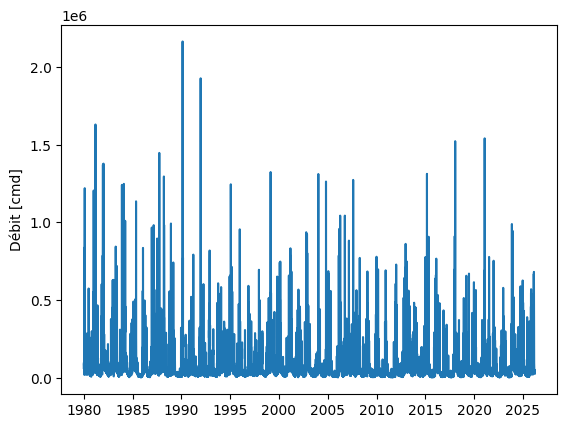

In [8]:
plt.plot(data.index, data['q_cmd'])
plt.ylabel('Débit [cmd]')

***2.1 Quelle est l'allure de la série de données?***
  
     grande variabilité


On va maintenant changer d'échelle et afficher le débit avec une échelle logarithmique.

***2.1 Qu'est qu'une échelle logarithmique? Pour quelles raisons cette échelle est utile ici?***
  
           échelle par ordre de grandeur, utilie quand il y a une grande variabiliét et que les valeurs changent d'ordre de grandeur.

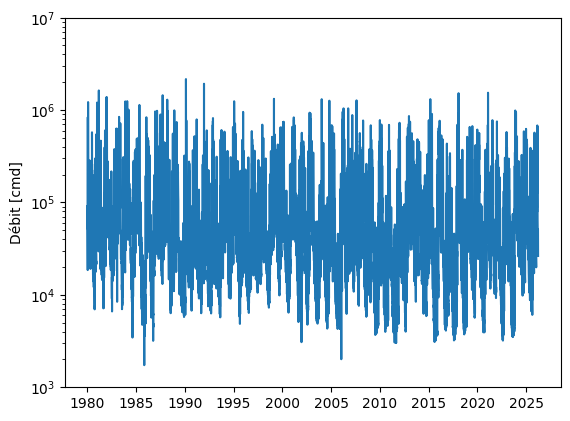

In [10]:
plt.plot(data.index, data['q_cmd'])
plt.ylabel('Débit [cmd]')

# On passe l'axe y sur une échelle logarithmique
plt.ylim([1000, 10000000])
plt.yscale('log')


***2.3 Quel est l'ordre de grandeur des valeurs minimales et des valeurs maximales?***
  
            10^6 et 10^3



## 3. Année hydrologique et statistiques globales sur la série de données

***3.1 Rappelez la définition d'année hydrologique? Complétez dans le code qui suit le numéro du mois à laquelle l'année hydrologique commence dans la zone géographique étudiée.***
  
période de 12 mois suivant le cycle hydrologique, début en CH: toute la neige accumulée depuis l’automne précédent a fondu

In [11]:
# Indiquez le mois auquel commence l'année hydrologique (1: janvier, 2: février, ...)
debut_hyear = 9

# On ajoute une colonne au tableau de données qui indiquent l'année hydrologique [hyear]
data['hyear'] = data.index.year + data.index.month//debut_hyear
data.head(3)

,q_cmd,hyear
time,,
1980-01-01,91458.0,1980
1980-01-02,78645.6,1980
1980-01-03,66733.2,1980


On veut maintenant calculer des statistiques sur l'ensemble de la série de données. Pour se faire on va garder seulement les années hydrologiques qui sont complètement couvertes par les mesures.

***3.2 À partir des dates de début et de fin de la chronique que vous avez relevée précedement, indiquez dans le code la première et la dernière année hydrologique de votre zone d'analyse. On considère que l'année dans laquelle se finit l'année hydrologique lui donne son nom.***

In [15]:
# Sélection  de la période d'analyse
# Complétez les années de début et de fin
debut_hyear = 1981
fin_hyear = 2025

# On sélectionne la période choisie
data = data[(data['hyear'] >= debut_hyear) & (data['hyear'] <= fin_hyear)]
# On vérifie si la série de données obtenues couvre bien la période voulue
print(data.head())
print(data.tail())

              q_cmd  hyear
time                      
1980-09-01  16146.0   1981
1980-09-02  13917.6   1981
1980-09-03  12841.2   1981
1980-09-04  12103.2   1981
1980-09-05  19587.6   1981
               q_cmd  hyear
time                       
2025-08-27   19778.4   2025
2025-08-28  362728.8   2025
2025-08-29  261475.2   2025
2025-08-30  107280.0   2025
2025-08-31   73249.2   2025


Le code qui suit calcule le débit moyen et l'écart type de la série de données. 

In [17]:
# On calcule le débit moyen et l'écart-type
q_mean = data['q_cmd'].mean()
q_std = data['q_cmd'].std()
print(f"Le débit moyen est de {q_mean:.2f} m3/d (écart-type: {q_std:.2f} m3/d)")

Le débit moyen est de 69478.71 m3/d (écart-type: 114790.47 m3/d)


***3.3 Rappelez la définition de débit spécifique. Quelle est l'intérêt de cette mesure?***
  
Le débit spécifique est une mesure de l'écoulement moyen des précipitations au sein du bassin versant d'un cours d'eau. Il se définit comme le volume d'eau qui s'écoule en moyenne chaque seconde par kilomètre carré du bassin[1]. C'est donc le rapport du débit Q du cours d'eau (exprimé en L/s ou m3/s) et de la surface A de son bassin versant (exprimée en km2)
            
***3.4 En utilisant la valeur moyenne de débit fournie par le code et l'air du bassin versant obtenue précédement. Calculez le débit spécifique de cette station de mesure. Indiquez aussi l'unité de cette grandeur. Commentez la valeur obtenue.***

 112km^2 = 1,12 * 10^8 m^2  -->  q = Q/A en m/j
            

In [26]:
# Complétez le code
area_bv = 112 #km2
qs_unit = 'mm/j'
qs = q_mean/(area_bv*10**6)*10**3

print(f"Le débit spécifique du bassin versant est de {qs:.2f} {qs_unit}")

Le débit spécifique du bassin versant est de 0.62 mm/j


## 4. Analyse des variations saisonnières et interannuelles
On s'intéresse maintenant à la manière dont le débit varie d'une année sur l'autre, d'un mois sur l'autre.

### Variabilité interannuelle

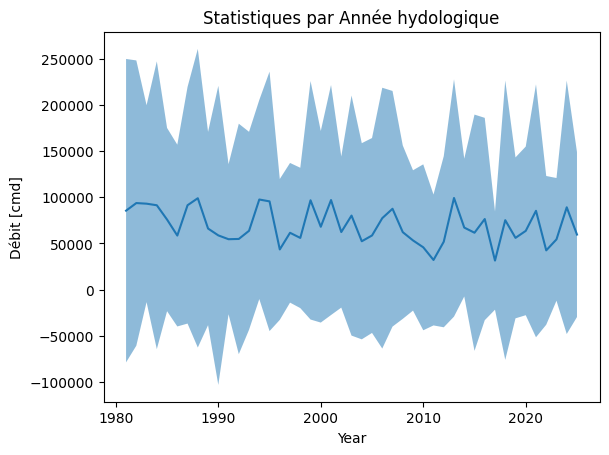

 débit minimal: 31407.425753424657 indice de l'année: 36
 débit minimal: 99209.21424657536 indice de l'année: 32


In [45]:
# On calcule le débit moyen et l'écart-type pour chaque année hydrologique
byHyear = data.groupby('hyear')
stat_hyear = byHyear['q_cmd'].agg(['mean', 'std'])
# On visualise les statistiques obtenues avec un graphique
visualize_stat(stat_hyear, 'Statistiques par Année hydologique', 'Year', 'Débit [cmd]')

print(f" débit minimal: {min(stat_hyear['mean'])} indice de l'année: {stat_hyear['mean'].argmin()}")
print(f" débit minimal: {max(stat_hyear['mean'])} indice de l'année: {stat_hyear['mean'].argmax()}")

***4.1 Quel est le débit moyen annuel le plus faible, le plus élevé ? Indiquez en quelle année ces valeurs sont atteintes ? Donnez des éléments de contexte vis-à-vis de ces dates.***
  
plus faible: 31'407 m3/j en 2017
plus fort: 99'209 m3/j en 2013

### Variabilité saisonnière

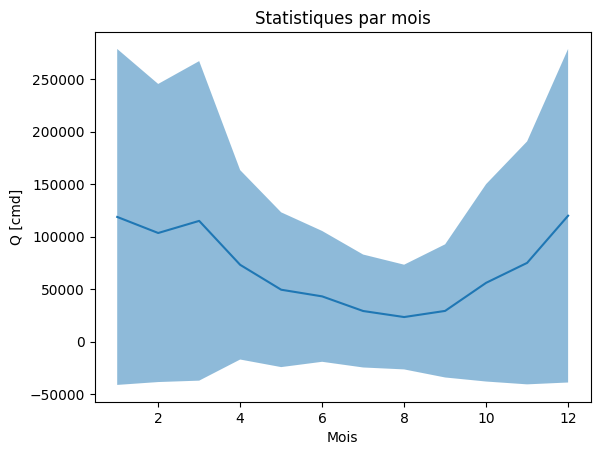

In [30]:
# Ajoutd'un colonne qui indique les mois de chaque mesure.
data['month'] = data.index.month

# On calcule le débit moyen et l'écart-type par mois de l'année
byMonth = data.groupby('month')    
stat_month = byMonth['q_cmd'].agg(['mean', 'std'])
visualize_stat(stat_month, 'Statistiques par mois', 'Mois', 'Q [cmd]')

***4.1 Quelles sont les périodes de plus fort débit ? Comment pouvez-vous l'expliquer ?***
  
décembre à mars, le plus de précipitations

***4.2 Quelle est la période de plus faible débits ? Comment pouvez-vous l'expliquer ?***

juillet à septembre, sécheresse

***4.3 En utilisant les informations fournies par l'OFEV (https://www.bafu.admin.ch/fr/regime-decoulement), donner la définition de régime d'écoulement et identifier celui de ce cours d'eau en vous justifiant.***
  
variation d'écoulement dans une période donnée, ici l'année
régime pluvial jurassien: on est dans le jura, il y a de la neige mais qui fond souvent rapidement.





## 5. Flow-Duration Curve

On va maintenant calculer la courbe débit-durée, plus communément appelée par son nom anglais: *flow-duration curve*.

***5.1 Qu'est-ce qu'une flow-duration curve ? Quel est l'intérêt de ce type de représentation ?***
  
            . . .

In [ ]:
# Flow duration curve
flow_duration_curve(data['q_cmd']) 

***5.2 En utilisant la courbe ci-dessus, donnez le débit médian de la station.***
  
            . . .

***5.3 Qu'est-ce que le débit environemental? Quel est l'intérêt de cette mesure?***
  
            . . .
            
***5.4 En utilisant la courbe ci-dessus, donnez le débit environemental de cette station.***
  
            . . .